/tmp/ipykernel_699/2775753894.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_rng = pd.date_range(start='2014-01-01', end='2023-12-31', freq='M')


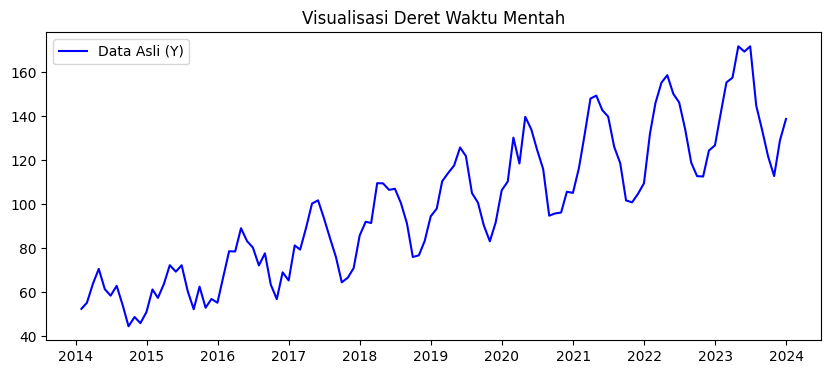

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Mensimulasikan Data Waktu Bulanan (10 Tahun = 120 bulan)
np.random.seed(42)
date_rng = pd.date_range(start='2014-01-01', end='2023-12-31', freq='M')

# Membuat Tren (Meningkat secara linier)
trend = np.linspace(50, 150, len(date_rng))

# Membuat Musiman (Pola gelombang berulang tiap 12 bulan)
# Amplitudo dibuat membesar seiring waktu untuk menstimulasi model multiplikatif
seasonality = 10 * np.sin(2 * np.pi * np.arange(len(date_rng)) / 12)
multiplier = np.linspace(1, 3, len(date_rng))
seasonal_effect = seasonality * multiplier

# Membuat Error / Noise acak
noise = np.random.normal(0, 5, len(date_rng))

# Menggabungkan komponen (Model Aditif)
y = trend + seasonal_effect + noise

# Memasukkan ke dalam DataFrame
df = pd.DataFrame(data={'Nilai': y}, index=date_rng)

# Plot Data Asli
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Nilai'], label='Data Asli (Y)', color='blue')
plt.title("Visualisasi Deret Waktu Mentah")
plt.legend()
plt.show()

Perhatikan grafik Resid (Irregular/Noise) yang dihasilkan oleh Python. Berkat penggunaan argumen robust=True pada STL, algoritma tidak membiarkan pencilan (outlier pada bulan ke-60) merusak grafik tren maupun musiman. Pencilan tersebut sukses diisolasi seutuhnya di dalam komponen Resid.

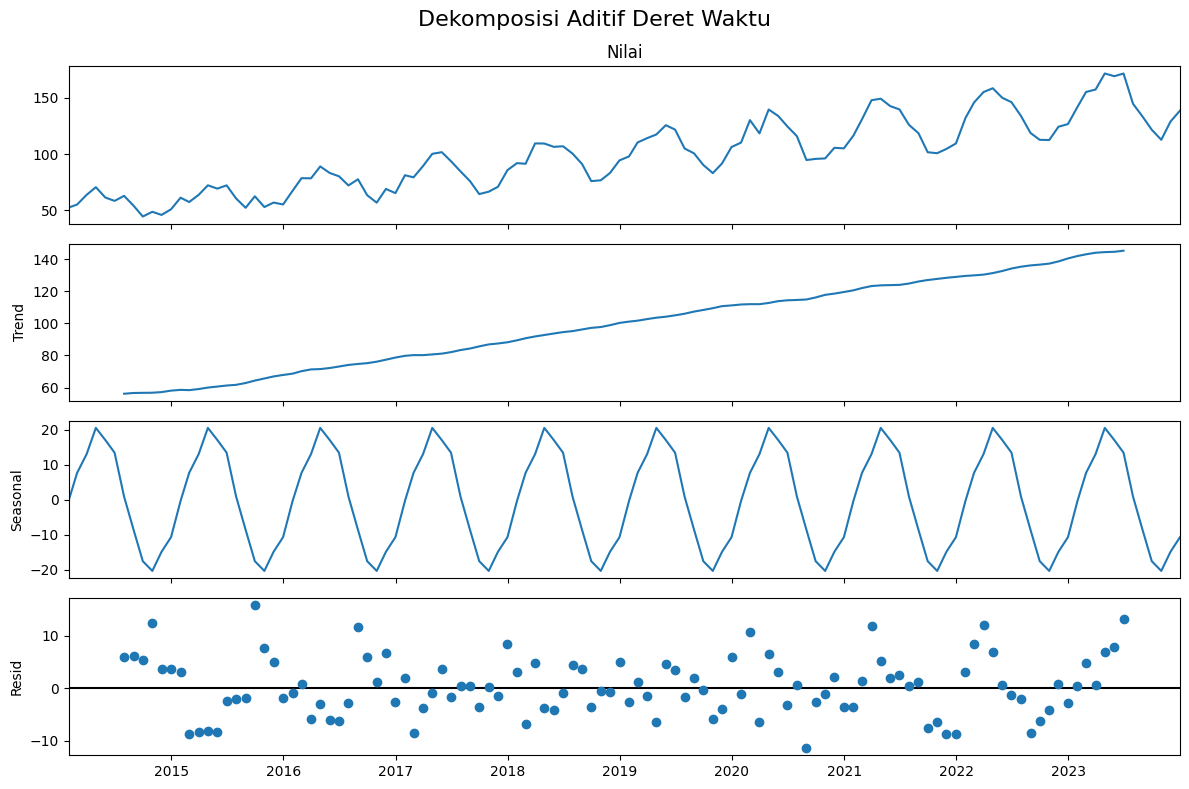

In [ ]:
# 2. Melakukan Dekomposisi (Asumsi Model Aditif)
decomposition_additive = seasonal_decompose(df['Nilai'], model='additive', period=12)

# Mengambil hasil ekstraksi tiap komponen
trend_est = decomposition_additive.trend
seasonal_est = decomposition_additive.seasonal
residual_est = decomposition_additive.resid

# 3. Plotting Hasil Dekomposisi secara keseluruhan
fig = decomposition_additive.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi Aditif Deret Waktu', fontsize=16)
plt.tight_layout()
plt.show()

Ubah argumen model='additive' menjadi model='multiplicative' pada fungsi dekomposisi di atas (pastikan seluruh nilai $Y > 0$). Amati bagaimana plot komponen residualnya berubah. Jika varians residual pada model multiplikatif tampak lebih konstan (merata) dibandingkan aditif, maka data tersebut pada realitanya berstruktur multiplikatif.

/tmp/ipykernel_699/779982281.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  waktu = pd.date_range(start='2014-01-01', end='2023-12-31', freq='M')


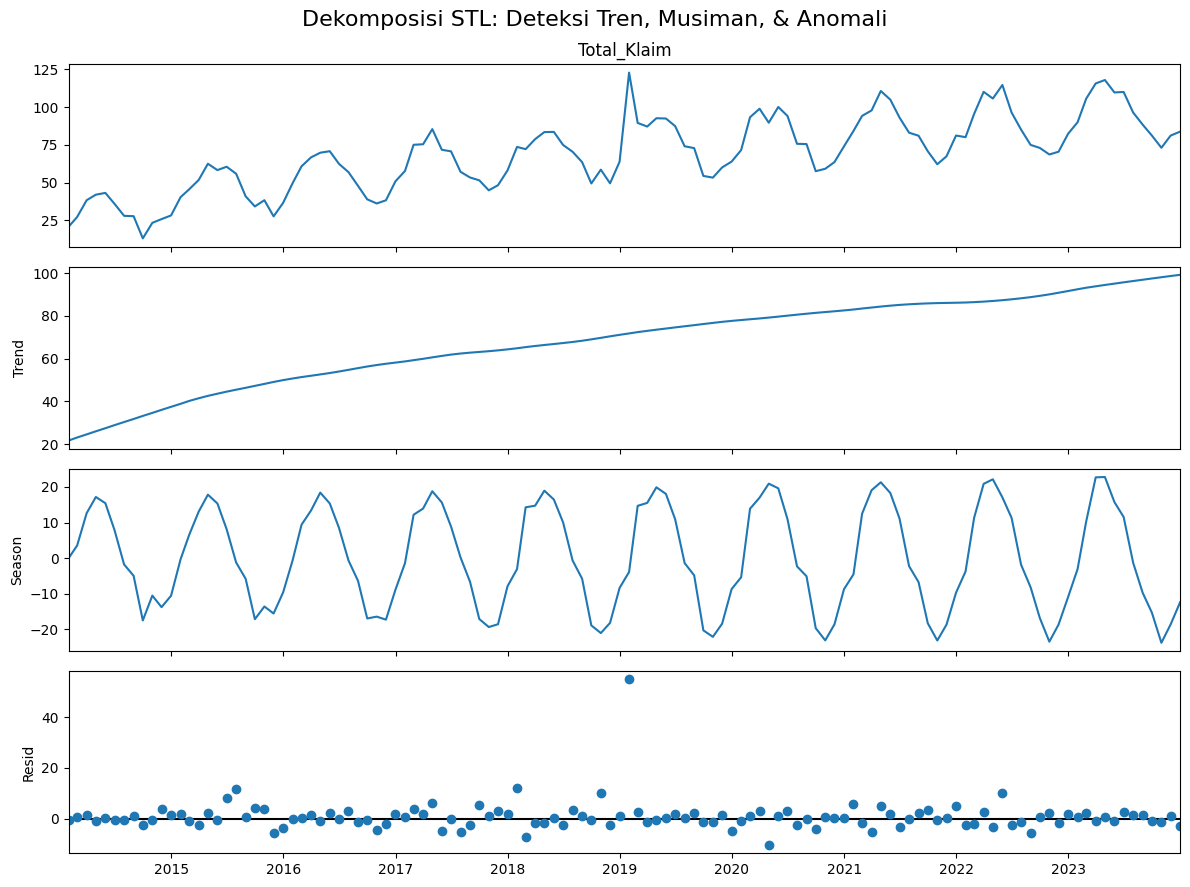

In [ ]:
# 1. Import Pustaka Utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 2. Simulasi Data Deret Waktu (Bulanan selama 10 Tahun)
np.random.seed(101)
waktu = pd.date_range(start='2014-01-01', end='2023-12-31', freq='M')
n_obs = len(waktu)

# Membuat Tren non-linier (Pertumbuhan yang mulai melandai)
tren = np.linspace(10, 50, n_obs) + 10 * np.log(np.arange(1, n_obs + 1))

# Membuat Pola Musiman dengan amplitudo yang sedikit membesar
musiman = 15 * np.sin(2 * np.pi * np.arange(n_obs) / 12)
musiman_dinamis = musiman * np.linspace(1, 1.5, n_obs)

# Menambahkan Noise (Irregular)
noise = np.random.normal(0, 4, n_obs)

# Menambahkan satu Outlier ekstrem (Irregular component) di bulan ke-60
noise[60] += 50

# Menggabungkan komponen
y = tren + musiman_dinamis + noise
df = pd.Series(y, index=waktu, name="Total_Klaim")

# 3. Proses Dekomposisi menggunakan STL
# period=12 untuk data bulanan, robust=True agar tahan terhadap outlier
stl = STL(df, period=12, robust=True)
hasil_dekomposisi = stl.fit()

# 4. Visualisasi Hasil Ekstraksi Komponen
fig = hasil_dekomposisi.plot()
fig.set_size_inches(12, 9)
plt.suptitle('Dekomposisi STL: Deteksi Tren, Musiman, & Anomali', fontsize=16)
plt.tight_layout()
plt.show()

Perhatikan grafik Resid (Irregular/Noise) yang dihasilkan oleh Python. Berkat penggunaan argumen robust=True pada STL, algoritma tidak membiarkan pencilan (outlier pada bulan ke-60) merusak grafik tren maupun musiman. Pencilan tersebut sukses diisolasi seutuhnya di dalam komponen Resid.

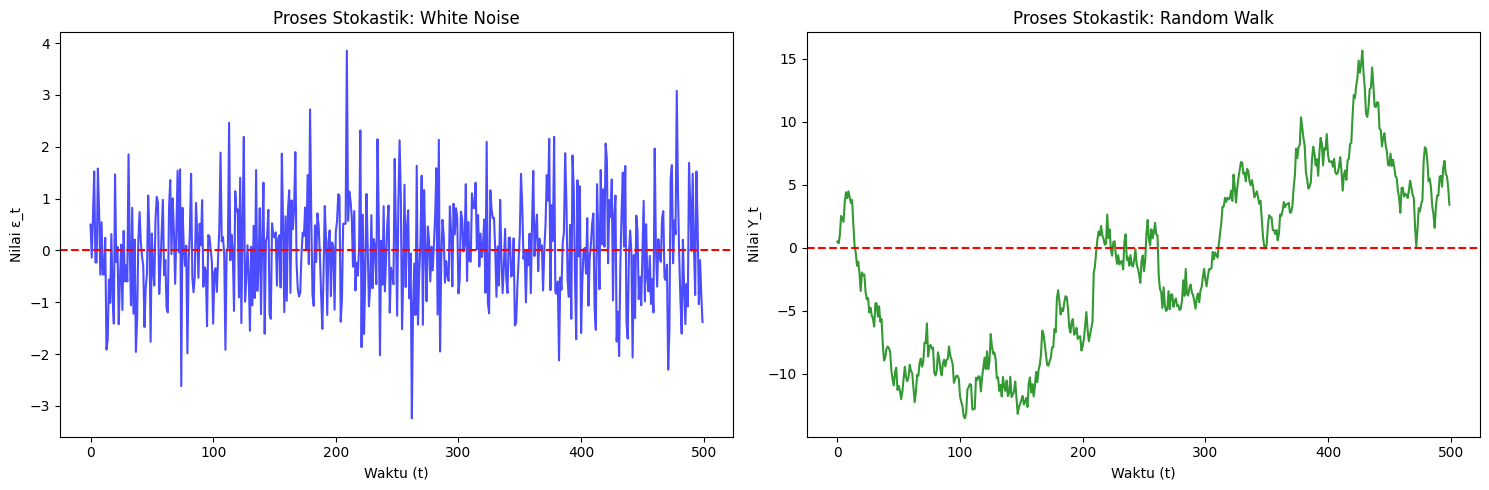

Varians dari 100 data pertama Random Walk: 21.35
Varians dari 500 data penuh Random Walk: 49.17


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tetapkan seed agar simulasi bisa direproduksi dengan hasil yang sama
np.random.seed(42)

# 1. Menentukan parameter waktu (Misal: 500 hari)
n_steps = 500

# 2. MENSIMULASIKAN WHITE NOISE
# Menghasilkan bilangan acak berdistribusi normal: N(0, 1)
white_noise = np.random.normal(loc=0, scale=1, size=n_steps)

# 3. MENSIMULASIKAN RANDOM WALK
# Random Walk adalah kumulatif jumlah dari White Noise
random_walk = np.cumsum(white_noise)

# 4. VISUALISASI PROSES STOKASTIK
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot White Noise
ax1.plot(white_noise, color='blue', alpha=0.7)
ax1.set_title('Proses Stokastik: White Noise')
ax1.set_xlabel('Waktu (t)')
ax1.set_ylabel('Nilai ε_t')
ax1.axhline(0, color='red', linestyle='--') # Garis rataan = 0

# Plot Random Walk
ax2.plot(random_walk, color='green', alpha=0.8)
ax2.set_title('Proses Stokastik: Random Walk')
ax2.set_xlabel('Waktu (t)')
ax2.set_ylabel('Nilai Y_t')
ax2.axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# 5. PEMBUKTIAN MATEMATIS RAGAM (VARIANCE)
print(f"Varians dari 100 data pertama Random Walk: {np.var(random_walk[:100]):.2f}")
print(f"Varians dari 500 data penuh Random Walk: {np.var(random_walk):.2f}")
# Output varians akan membuktikan bahwa seiring berjalannya waktu (t),
# penyebaran data (ragam) membesar, bukti ketidakstasioneran.

Ganti nilai parameter loc=0 menjadi loc=0.5. Ini akan menciptakan simulasi Random Walk with Drift (Langkah acak yang ditarik secara perlahan membentuk tren jangka panjang ke atas, sering menjadi karakteristik data saham blue-chip jangka panjang).

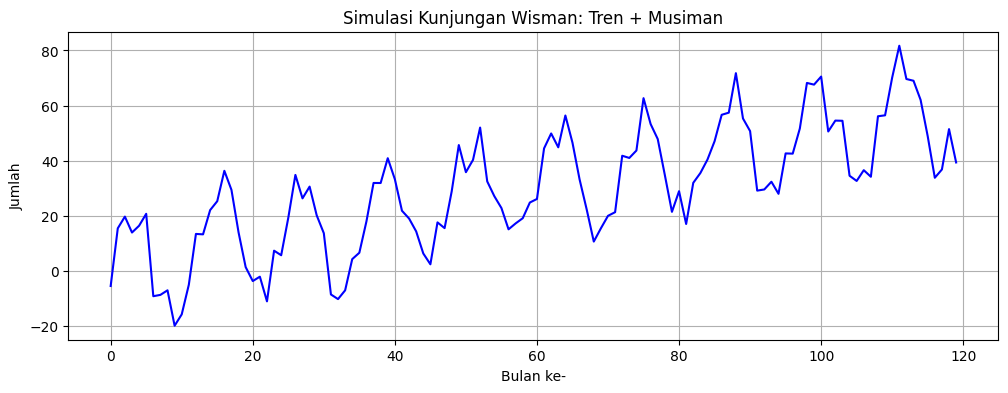

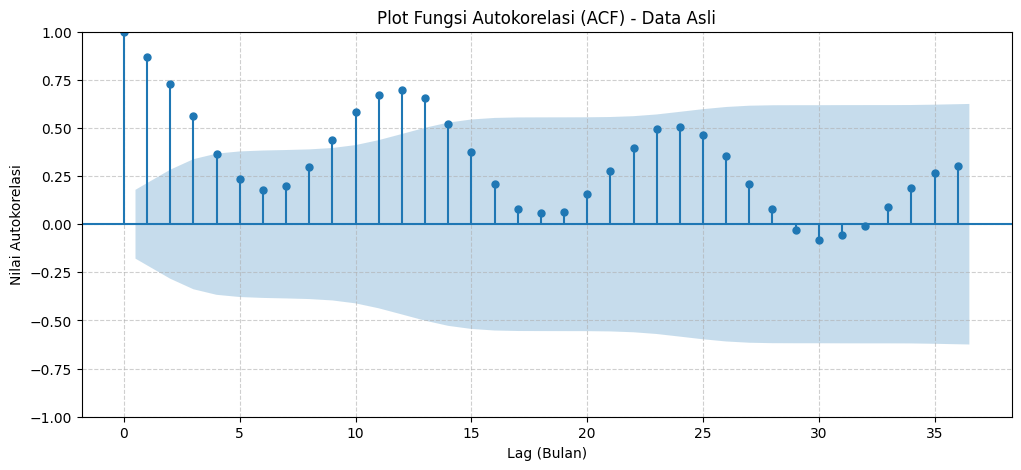

In [ ]:
# 1. Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 2. Simulasi Data (Menyerupai Data Wisatawan: Tren + Musiman)
np.random.seed(123)
n_months = 120 # Data bulanan selama 10 tahun
time = np.arange(n_months)

# Membuat komponen tren naik perlahan
trend = 0.5 * time

# Membuat komponen musiman (Puncak di bulan ke-7 dan ke-12)
seasonal = 20 * np.sin(2 * np.pi * time / 12)

# Membuat komponen noise (acak)
noise = np.random.normal(0, 5, n_months)

# Menggabungkan data
y = trend + seasonal + noise
df = pd.DataFrame({'Wisman': y})

# 3. Plotting Data Deret Waktu Asli
plt.figure(figsize=(12, 4))
plt.plot(df['Wisman'], color='blue')
plt.title('Simulasi Kunjungan Wisman: Tren + Musiman')
plt.xlabel('Bulan ke-')
plt.ylabel('Jumlah')
plt.grid(True)
plt.show()

# 4. Membangun Plot ACF (Correlogram)
fig, ax = plt.subplots(figsize=(12, 5))

# lags=36 untuk melihat pola musiman hingga 3 tahun ke belakang
plot_acf(df['Wisman'], lags=36, ax=ax, alpha=0.05)
plt.title('Plot Fungsi Autokorelasi (ACF) - Data Asli')
plt.xlabel('Lag (Bulan)')
plt.ylabel('Nilai Autokorelasi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Setelah Anda menjalankan kode di atas, perhatikan plot ACF yang dihasilkan. Anda akan melihat batas area berwarna biru (interval kepercayaan 95%). Batang hitam yang menjulang di atas area biru menandakan autokorelasi yang signifikan. Anda akan melihat pola meluruh (decay) di lag-lag awal karena efek variabel trend, diselingi gelombang yang mencuat setiap kelipatan lag 12 karena variabel seasonal.

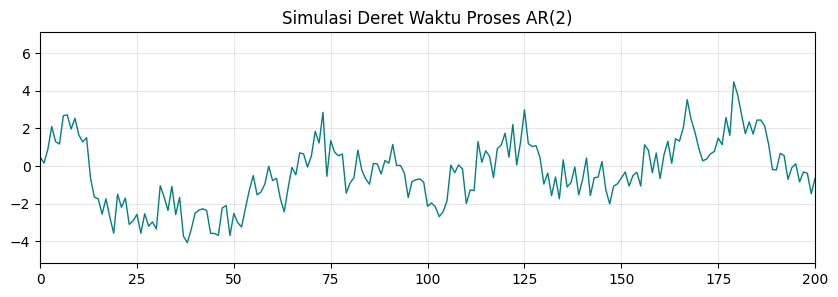

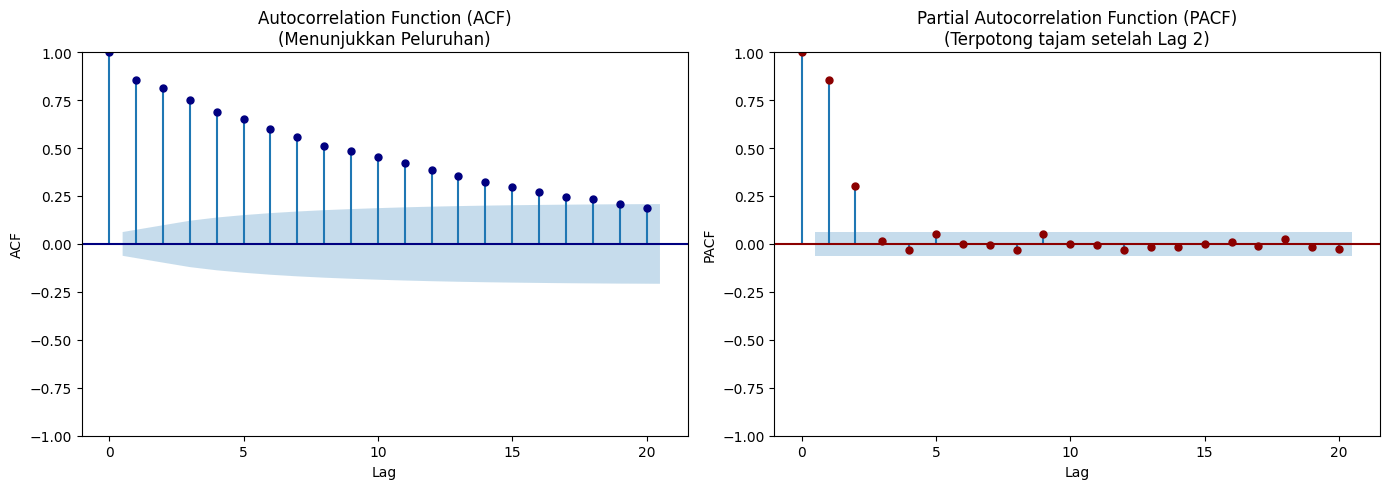

In [ ]:
# 1. Import library yang dibutuhkan
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2. Simulasi Proses Autoregressive AR(2)
# Persamaan matematis: Y_t = 0.6*Y_{t-1} + 0.3*Y_{t-2} + e_t
# Dalam statsmodels, parameter AR harus diawali dengan 1 dan diberi tanda negatif untuk koefisiennya
ar_params = np.array([1, -0.6, -0.3])
ma_params = np.array([1]) # Tidak ada komponen MA

# Membangun objek ARMA process
ar_process = ArmaProcess(ar_params, ma_params)

# Mengenerate 1000 sampel data simulasi
np.random.seed(42)
y_simulasi = ar_process.generate_sample(nsample=1000)

# 3. Visualisasi Deret Waktu Asli
plt.figure(figsize=(10, 3))
plt.plot(y_simulasi, color='teal', linewidth=1)
plt.title('Simulasi Deret Waktu Proses AR(2)')
plt.xlim(0, 200) # Zoom pada 200 observasi pertama
plt.grid(True, alpha=0.3)
plt.show()

# 4. Membandingkan Plot ACF dan PACF secara berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot ACF: Menunjukkan pola 'Tails Off' (meluruh perlahan)
plot_acf(y_simulasi, lags=20, ax=ax1, color='navy')
ax1.set_title('Autocorrelation Function (ACF)\n(Menunjukkan Peluruhan)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')

# Plot PACF: Menunjukkan pola 'Cuts Off' (terpotong tajam setelah lag 2)
# method='ywm' (Yule-Walker) direkomendasikan untuk stabilitas perhitungan
plot_pacf(y_simulasi, lags=20, ax=ax2, method='ywm', color='darkred')
ax2.set_title('Partial Autocorrelation Function (PACF)\n(Terpotong tajam setelah Lag 2)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('PACF')

plt.tight_layout()
plt.show()

Perhatikan grafik PACF yang berwarna merah gelap. Anda akan melihat secara sangat jelas bahwa hanya garis pada lag 1 dan lag 2 yang menjulang menembus area biru (pita signifikansi). Mulai lag 3 dan seterusnya, garisnya seketika "mati" atau berada di dalam area batas toleransi acak. Inilah bukti empiris kekuatan PACF dalam mengidentifikasi parameter $p$ dalam pemodelan.

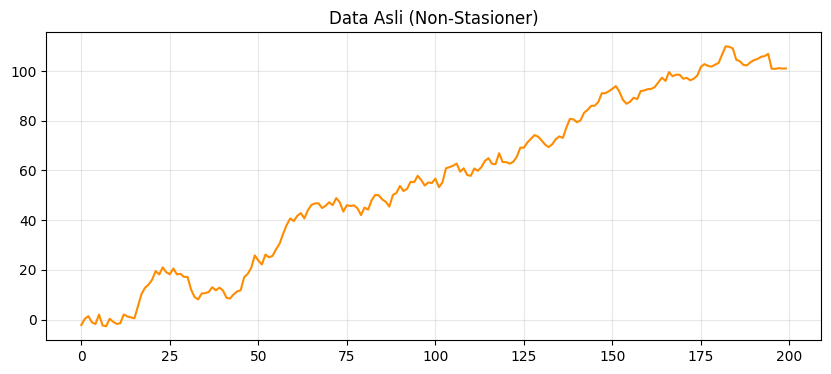

MENGUJI DATA ASLI:
--- Augmented Dickey-Fuller Test ---
ADF Statistic: -1.0894
p-value: 0.7193
Kesimpulan: Gagal Tolak H0, Data TIDAK STASIONER.

--- KPSS Test ---
KPSS Statistic: 2.0612
p-value: 0.0100
Kesimpulan: Tolak H0, Data TIDAK STASIONER.



/tmp/ipykernel_3802/818663642.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')


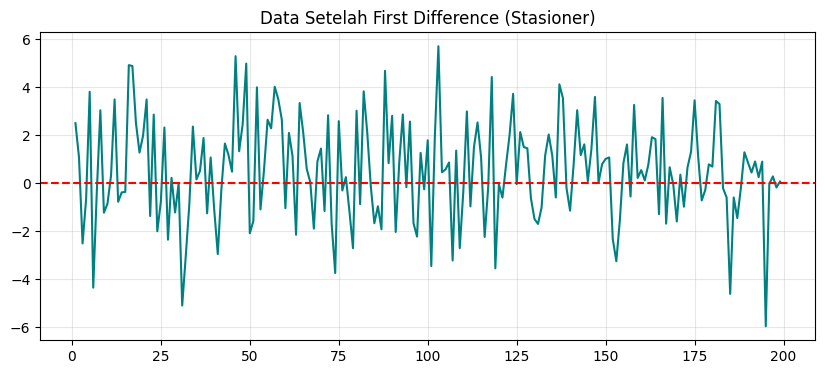

MENGUJI DATA DIFFERENCED:
--- Augmented Dickey-Fuller Test ---
ADF Statistic: -13.5442
p-value: 0.0000
Kesimpulan: Tolak H0, Data STASIONER.
--- KPSS Test ---
KPSS Statistic: 0.0841
p-value: 0.1000
Kesimpulan: Gagal Tolak H0, Data STASIONER.



/tmp/ipykernel_3802/818663642.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# 1. GENERATE DATA SIMULASI (Non-Stasioner: Random Walk dengan Tren)
np.random.seed(123)
n = 200
t = np.arange(n)
# Y_t = 0.5*t + Random Walk + Noise
y_non_stationary = 0.5 * t + np.cumsum(np.random.normal(0, 2, n))
df = pd.DataFrame({'Nilai': y_non_stationary})

# 2. VISUALISASI DATA AWAL
plt.figure(figsize=(10, 4))
plt.plot(df['Nilai'], color='darkorange')
plt.title('Data Asli (Non-Stasioner)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. FUNGSI UJI ADF (Augmented Dickey-Fuller)
# H0: Data memiliki Unit Root (TIDAK Stasioner)
# H1: Data Stasioner
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print("--- Augmented Dickey-Fuller Test ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Kesimpulan: Tolak H0, Data STASIONER.")
    else:
        print("Kesimpulan: Gagal Tolak H0, Data TIDAK STASIONER.\n")

# 4. FUNGSI UJI KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
# H0: Data Stasioner (di sekitar nilai tengah atau tren)
# H1: Data TIDAK Stasioner (memiliki Unit Root)
def kpss_test(series):
    # 'c' berarti menguji stasioneritas di sekitar nilai konstan
    result = kpss(series, regression='c', nlags='auto')
    print("--- KPSS Test ---")
    print(f"KPSS Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Kesimpulan: Tolak H0, Data TIDAK STASIONER.\n")
    else:
        print("Kesimpulan: Gagal Tolak H0, Data STASIONER.\n")

# Menjalankan uji pada data mentah
print("MENGUJI DATA ASLI:")
adf_test(df['Nilai'])
kpss_test(df['Nilai'])

# 5. TRANSFORMASI DATA (First Difference)
df['Nilai_Diff'] = df['Nilai'].diff().dropna()

# Visualisasi Data Setelah Differencing
plt.figure(figsize=(10, 4))
plt.plot(df['Nilai_Diff'], color='teal')
plt.title('Data Setelah First Difference (Stasioner)')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# Menjalankan uji pada data differenced
print("MENGUJI DATA DIFFERENCED:")
adf_test(df['Nilai_Diff'].dropna())
kpss_test(df['Nilai_Diff'].dropna())

Uji ADF dan KPSS memiliki hipotesis nol ($H_0$) yang berlawanan. Data yang benar-benar stasioner harus menghasilkan p-value $< 0.05$ pada uji ADF (Tolak $H_0$), DAN p-value $> 0.05$ pada uji KPSS (Gagal Tolak $H_0$).

Apakah MA dengan koef. 0.5 Invertibel? True
Apakah MA dengan koef. 2.0 Invertibel? False

Akar MA (0.5): [-2.]
Akar MA (2.0): [-0.5]


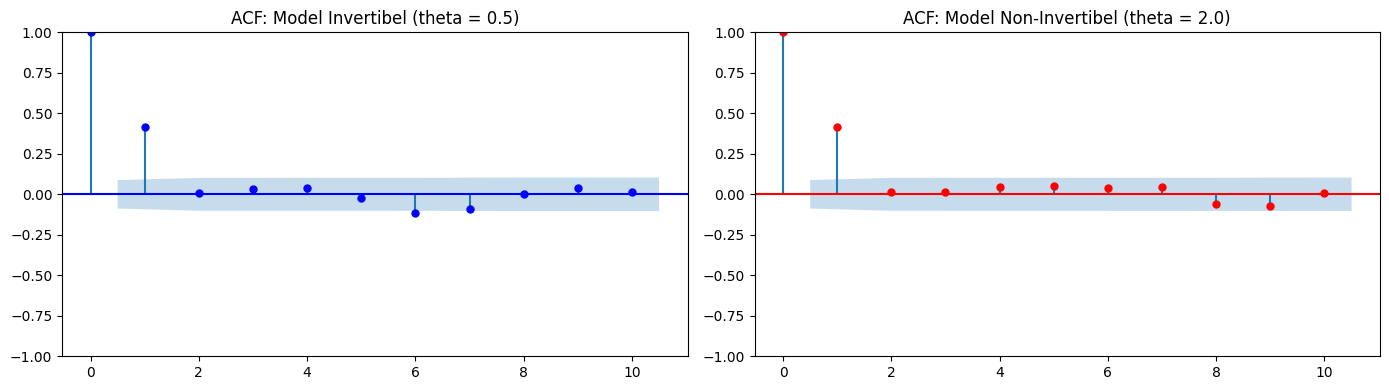

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf

# 1. Mendefinisikan dua proses MA(1) yang berpasangan
# Ingat: statsmodels mendefinisikan MA polynomial dengan tanda positif
# (1 + theta*B), sehingga tanda parameter berlawanan dengan konvensi buku teks tertentu.
ma_params_invertible = np.array([1, 0.5])  # theta = -0.5 (Invertibel: |0.5| < 1)
ma_params_noninvertible = np.array([1, 2.0]) # theta = -2.0 (Non-Invertibel: |2.0| > 1)
ar_params = np.array([1]) # Tidak ada komponen AR

# 2. Membangun objek Proses
process_inv = ArmaProcess(ar_params, ma_params_invertible)
process_non = ArmaProcess(ar_params, ma_params_noninvertible)

# 3. Uji Invertibilitas Bawaan Python
print(f"Apakah MA dengan koef. 0.5 Invertibel? {process_inv.isinvertible}")
print(f"Apakah MA dengan koef. 2.0 Invertibel? {process_non.isinvertible}")

# 4. Melihat Akar Polinomial Karakteristik
print(f"\nAkar MA (0.5): {process_inv.maroots}") # Harus di luar unit circle (>1)
print(f"Akar MA (2.0): {process_non.maroots}") # Akan di dalam unit circle (<1)

# 5. Simulasi Data dan Perbandingan Plot ACF
np.random.seed(123)
data_inv = process_inv.generate_sample(nsample=500)
data_non = process_non.generate_sample(nsample=500)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot ACF untuk model Invertibel
plot_acf(data_inv, lags=10, ax=axes[0], color='blue')
axes[0].set_title('ACF: Model Invertibel (theta = 0.5)')

# Plot ACF untuk model Non-Invertibel
plot_acf(data_non, lags=10, ax=axes[1], color='red')
axes[1].set_title('ACF: Model Non-Invertibel (theta = 2.0)')

plt.tight_layout()
plt.show()

Ketika Anda mengeksekusi kode di atas, Anda akan melihat bahwa process_inv.isinvertible mengembalikan nilai True karena akarnya bernilai $-2.0$ (secara absolut lebih besar dari $1$). Sebaliknya, proses non-invertibel mengembalikan False karena akarnya berada di dalam lingkaran satuan ($-0.5$). Meski akar karakteristiknya berbeda, grafik ACF dari kedua proses tersebut nyaris tidak bisa dibedakan. Python dan software analitik lainnya selalu menggunakan akar invertibel sebagai default pencarian regresi.